## Config

In [2]:
%pip install torch
%pip install torchvision
%pip install ultralytics
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import torchvision.transforms as transforms

DATASET_PATH = "resources/GTSRB/Final_Training/Images"

IMG_SIZE = 32
BATCH_SIZE = 32
NUM_CLASSES = 43
EPOCHS = 10

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GTSRB_labels = {
    0: "Speed limit (20km/h)",
    1: "Speed limit (30km/h)",
    2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)",
    4: "Speed limit (70km/h)",
    5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)",
    7: "Speed limit (100km/h)",
    8: "Speed limit (120km/h)",
    9: "No passing",
    10: "No passing for vehicles over 3.5 tons",
    11: "Right-of-way at the next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve to the left",
    20: "Dangerous curve to the right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or turn right",
    37: "Go straight or turn left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing by vehicles over 3.5 tons"
}

## Dataset

In [4]:
import os
from PIL import Image
from torch.utils.data import Dataset


class TrafficSignDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []

        for class_id in range(NUM_CLASSES):
            class_path = os.path.join(root_dir, f"{class_id:05d}")
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                if img_name.endswith('.ppm'):
                    self.images.append(img_path)
                    self.labels.append(class_id)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

## CNN

In [7]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights, densenet121, DenseNet121_Weights

class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes = NUM_CLASSES):
        super(TrafficSignCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


def get_model(model_name='ResNet18'):
    num_classes = 43
    
    if model_name == 'ResNet18':
        model = resnet18(weights=ResNet18_Weights.DEFAULT)

        for param in model.parameters():
            param.requires_grad = False
        for name, param in model.named_parameters():
            if "layer4" in name or "fc" in name:
                param.requires_grad = True

        model.fc = nn.Sequential(
            nn.Linear(model.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        return model.to(device)

    elif model_name == 'densenet121':
        model = densenet121(weights=DenseNet121_Weights.DEFAULT)

        for param in model.parameters():
            param.requires_grad = True
    
        model.classifier = nn.Sequential(
            nn.Linear(model.classifier.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
        return model.to(device)
        
    elif model_name == 'CNN':
        model = TrafficSignCNN()
        return model.to(device)
    
    raise ValueError("Unsupported model: {}".format(model_name))


def get_optimizer(model):
    return optim.Adam(model.parameters(), lr=0.001)


def get_criterion():
    return nn.CrossEntropyLoss()

## Train function

In [8]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


def train_model(model_name, EPOCHS):
    dataset = TrafficSignDataset(DATASET_PATH, transform=transform)

    train_size = int(0.75 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    net = get_model(model_name)
    criterion = get_criterion()
    optimizer = get_optimizer(net)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(EPOCHS):
        net.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = correct / total
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        net.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = net(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_val_loss = val_loss / len(test_loader)
        epoch_val_acc = correct / total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        print(f"Epoch {epoch + 1}/{EPOCHS} | "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    print("Training Complete")
    torch.save(net.state_dict(), f"app/classifiers/{model_name}.pth")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=list(GTSRB_labels.values())))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap="Blues", xticklabels=list(GTSRB_labels.values()), yticklabels=list(GTSRB_labels.values()), annot=False, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


def load_model(model_path='model.pth'):
    net = get_model().to(device)
    net.load_state_dict(torch.load(model_path))
    net.eval()
    return net


def predict_image(image_path):
    from PIL import Image
    net = load_model()

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = net(image)
        _, predicted_class = torch.max(output, 1)

    return predicted_class.item()

## Train + Test CNN

In [ ]:
train_model('CNN', 10)

## Train + Test ResNet18

Epoch 1/14 | Train Loss: 1.5318, Train Acc: 0.5406 | Val Loss: 0.8534, Val Acc: 0.7246
Epoch 2/14 | Train Loss: 0.9169, Train Acc: 0.7145 | Val Loss: 0.5724, Val Acc: 0.8157
Epoch 3/14 | Train Loss: 0.6808, Train Acc: 0.7902 | Val Loss: 0.4667, Val Acc: 0.8474
Epoch 4/14 | Train Loss: 0.5517, Train Acc: 0.8299 | Val Loss: 0.3936, Val Acc: 0.8737
Epoch 5/14 | Train Loss: 0.4742, Train Acc: 0.8530 | Val Loss: 0.3341, Val Acc: 0.8948
Epoch 6/14 | Train Loss: 0.4145, Train Acc: 0.8737 | Val Loss: 0.3281, Val Acc: 0.8987
Epoch 7/14 | Train Loss: 0.3651, Train Acc: 0.8884 | Val Loss: 0.2735, Val Acc: 0.9157
Epoch 8/14 | Train Loss: 0.3264, Train Acc: 0.9018 | Val Loss: 0.2303, Val Acc: 0.9325
Epoch 9/14 | Train Loss: 0.2994, Train Acc: 0.9083 | Val Loss: 0.2599, Val Acc: 0.9231
Epoch 10/14 | Train Loss: 0.2801, Train Acc: 0.9171 | Val Loss: 0.2102, Val Acc: 0.9350
Epoch 11/14 | Train Loss: 0.2615, Train Acc: 0.9200 | Val Loss: 0.2123, Val Acc: 0.9334
Epoch 12/14 | Train Loss: 0.2549, Train A

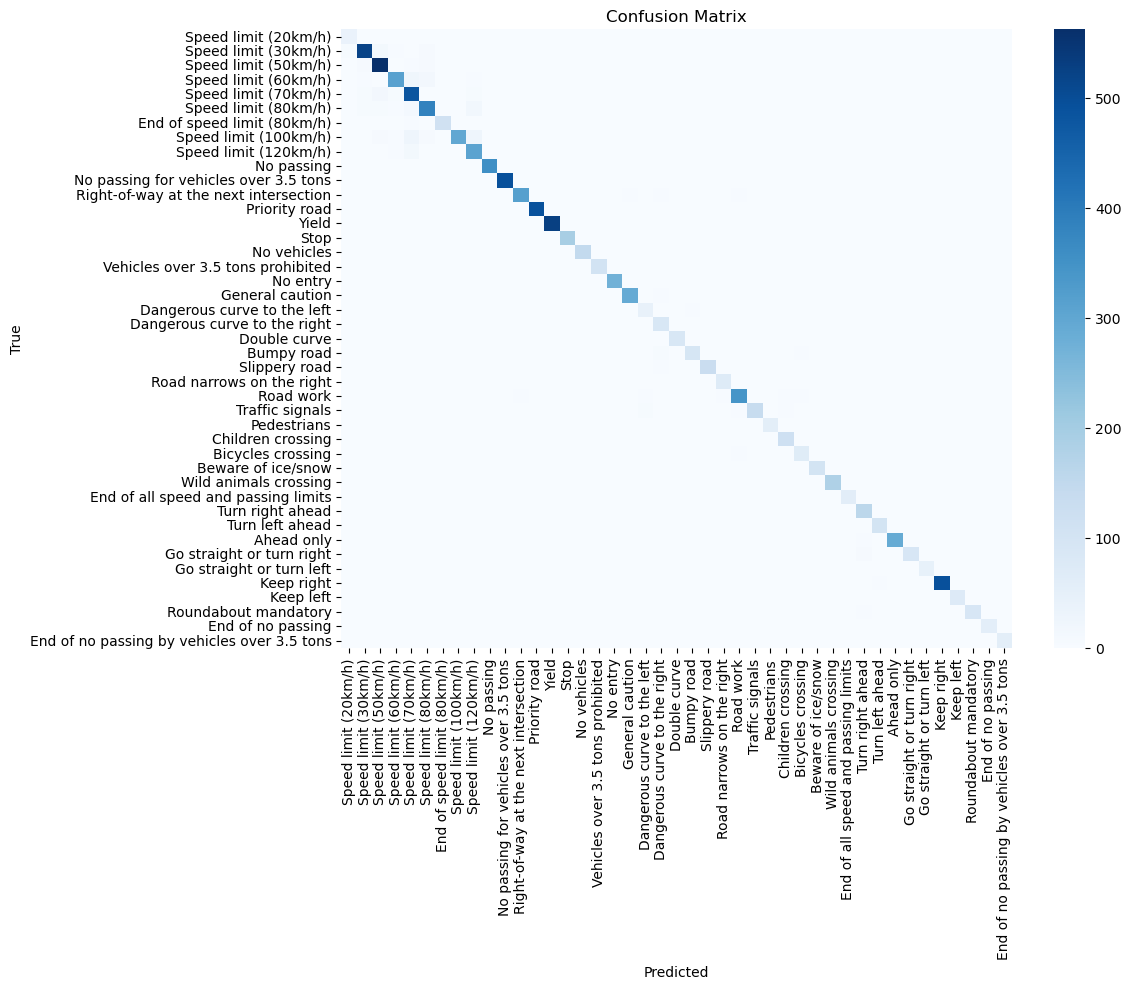

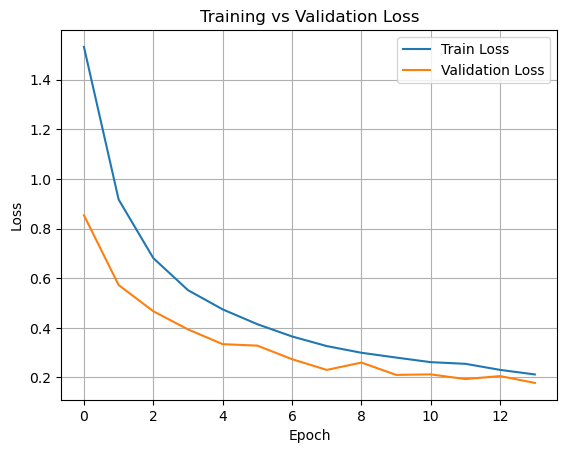

In [9]:
train_model('ResNet18', 14)